# Variational Autoencoder for Medical Imaging: Chest X-Ray Generation

## Learning Objectives
By the end of this notebook, you will:
1. Understand the mathematical foundations of Variational Autoencoders (VAEs)
2. Implement a VAE with U-Net architecture for medical image generation
3. Master the reparameterization trick for backpropagation through stochastic nodes
4. Evaluate generative models using appropriate metrics
5. Apply VAEs to real medical imaging data (chest X-rays)

---

## 1. Introduction to Variational Autoencoders

### What is a VAE?

A **Variational Autoencoder (VAE)** is a generative model that learns to encode data into a latent space and decode it back, while ensuring the latent space has nice properties for generation. Unlike standard autoencoders, VAEs:

- Learn a **probability distribution** over the latent space
- Can **generate new samples** by sampling from this distribution
- Use the **reparameterization trick** to enable backpropagation

### Key Components:

1. **Encoder**: Maps input x → latent distribution parameters (μ, σ)
2. **Reparameterization**: z = μ + σ ⊙ ε, where ε ~ N(0, I)
3. **Decoder**: Maps latent z → reconstructed output x̂
4. **Loss Function**: ELBO = Reconstruction Loss + KL Divergence


## 2. Setup and Imports


In [1]:
# Install required packages if needed
import subprocess
import sys

def install_package(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", package, "-q"])

# Install required packages
packages = ['torch', 'torchvision', 'numpy', 'matplotlib', 'Pillow', 'tqdm', 'scikit-learn', 'seaborn']
for package in packages:
    try:
        __import__(package)
    except ImportError:
        print(f"Installing {package}...")
        install_package(package)


Installing Pillow...
Installing scikit-learn...


In [2]:
# Core imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder

# Utilities
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os
import time
import warnings
import zipfile
import urllib.request
from tqdm import tqdm
from sklearn.metrics import mean_squared_error
from typing import Tuple, Optional

warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print(f"PyTorch Version: {torch.__version__}")
print(f"Torchvision Version: {torchvision.__version__}")


PyTorch Version: 2.7.1+cpu
Torchvision Version: 0.22.1+cpu


## 3. Device Configuration


In [5]:
def get_device() -> torch.device:
    """
    Automatically detect and return the best available device.
    
    Returns:
        torch.device: CUDA device if available, MPS for Mac Silicon, else CPU
    """
    if torch.cuda.is_available():
        device = torch.device("cuda")
        print(f"🚀 Using CUDA GPU: {torch.cuda.get_device_name(0)}")
        print(f"   Memory Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    elif torch.backends.mps.is_available():
        device = torch.device("mps")
        print("🍎 Using Apple Silicon GPU (MPS)")
    else:
        device = torch.device("cpu")
        print("💻 Using CPU")
    
    return device

device = get_device()

# Set random seeds for reproducibility
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


💻 Using CPU


## 4. Data Loading and Preprocessing

### Downloading Chest X-Ray Dataset

We'll use a subset of chest X-ray images. For this demo, we'll use the NIH Chest X-ray dataset (simplified version).


In [12]:
def download_chest_xray_data(data_dir='./data'):
    """
    Download a real chest X-ray dataset.
    Using the NIH Chest X-ray14 dataset subset for educational purposes.
    """
    os.makedirs(data_dir, exist_ok=True)
    
    # Use a publicly available chest X-ray dataset
    # NIH Chest X-ray14 is a large dataset, we'll use a subset
    url = "https://www.kaggle.com/datasets/nih-chest-xrays/sample"
    
    # For this demo, we'll create a function that downloads from a more accessible source
    # In practice, you'd need to register with NIH and download the full dataset
    chest_xray_dir = os.path.join(data_dir, "chest_xray_images")
    
    if not os.path.exists(chest_xray_dir):
        print("Setting up chest X-ray dataset...")
        print("Note: For educational purposes, we'll use a sample dataset.")
        print("For production use, download the full NIH Chest X-ray14 dataset.")
        
        try:
            # Try to download from a more accessible source
            # This is a sample dataset that's publicly available
            sample_url = "https://github.com/ieee8023/covid-chestxray-dataset/archive/master.zip"
            zip_path = os.path.join(data_dir, "sample_chest_xray.zip")
            
            print("Downloading sample chest X-ray images...")
            urllib.request.urlretrieve(sample_url, zip_path)
            
            print("Extracting dataset...")
            with zipfile.ZipFile(zip_path, 'r') as zip_ref:
                zip_ref.extractall(data_dir)
            
            # Find and organize images
            extracted_dir = os.path.join(data_dir, "covid-chestxray-dataset-master")
            if os.path.exists(extracted_dir):
                # Look for image files in subdirectories
                for root, dirs, files in os.walk(extracted_dir):
                    for file in files:
                        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                            # Create target directory
                            os.makedirs(chest_xray_dir, exist_ok=True)
                            # Copy image to our organized directory
                            src_path = os.path.join(root, file)
                            dst_path = os.path.join(chest_xray_dir, file)
                            import shutil
                            shutil.copy2(src_path, dst_path)
            
            print("Real chest X-ray dataset ready!")
            print(f"Images stored in: {chest_xray_dir}")
            
        except Exception as e:
            print(f"Could not download real dataset: {e}")
            print("Please manually download chest X-ray images and place them in:")
            print(f"   {chest_xray_dir}")
            print("Or use the synthetic data fallback...")
            create_synthetic_chest_xray_data(data_dir)
    else:
        print("Real chest X-ray dataset already exists!")
        print(f"Using images from: {chest_xray_dir}")
    
    return chest_xray_dir


### Custom Dataset Class


In [13]:
# Download real chest X-ray data
print("Setting up real chest X-ray dataset...")
data_path = download_chest_xray_data('./data')

# Verify the data path exists and contains images
if os.path.exists(data_path):
    image_files = [f for f in os.listdir(data_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    print(f"Found {len(image_files)} chest X-ray images")
    if len(image_files) > 0:
        print(f"Dataset ready at: {data_path}")
        print(f"Sample files: {image_files[:3]}...")  # Show first 3 files
    else:
        print("No image files found in dataset directory")
        print("Please ensure chest X-ray images are available in the data directory")
else:
    print("Dataset directory not found")
    print("Please run the data download function first")


Setting up real chest X-ray dataset...
Real chest X-ray dataset already exists!
Using images from: ./data\chest_xray_images
Found 1142 chest X-ray images
Dataset ready at: ./data\chest_xray_images
Sample files: ['000001-1.jpg', '000001-1.png', '000001-10.jpg']...


In [27]:
class ChestXRayDataset(Dataset):
    """
    Custom Dataset for loading chest X-ray images.
    """
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = [f for f in os.listdir(root_dir) if f.endswith(('.png', '.jpg', '.jpeg'))]
        
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.images[idx])
        
        # Load image
        image = Image.open(img_path).convert('L')  # Convert to grayscale
        
        if self.transform:
            image = self.transform(image)
        
        return image

# Define transformations
img_size = 128  # Using 128x128 for faster training

transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])  # Normalize to [-1, 1]
])

# Create dataset
dataset = ChestXRayDataset(data_path, transform=transform)

# Split into train and validation
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Create data loaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"   Dataset Statistics:")
print(f"   Total samples: {len(dataset)}")
print(f"   Training samples: {train_size}")
print(f"   Validation samples: {val_size}")
print(f"   Batch size: {batch_size}")
print(f"   Image dimensions: {img_size}x{img_size}")


   Dataset Statistics:
   Total samples: 1136
   Training samples: 908
   Validation samples: 228
   Batch size: 32
   Image dimensions: 128x128


## 5. VAE Architecture with U-Net Components

### Understanding the Architecture

The VAE consists of:
1. **U-Net Encoder**: Progressively downsamples while preserving features through skip connections
2. **Latent Space**: Learns mean (μ) and log-variance (log σ²) for the latent distribution
3. **Reparameterization**: Samples z = μ + σ ⊙ ε
4. **U-Net Decoder**: Progressively upsamples using transposed convolutions


In [36]:
class ConvBlock(nn.Module):
    """
    Basic convolutional block with BatchNorm and ReLU.
    Building block for U-Net architecture.
    """
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super(ConvBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size, padding=padding)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        
    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        return x


In [51]:
class VAE_UNet(nn.Module):
    """
    Variational Autoencoder with U-Net-inspired architecture.
    
    The encoder uses convolutional blocks to extract features,
    the latent space models a Gaussian distribution,
    and the decoder reconstructs the image.
    """
    def __init__(self, in_channels=1, latent_dim=128):
        super(VAE_UNet, self).__init__()
        self.latent_dim = latent_dim
        
        # ============ ENCODER ============
        # Progressively reduce spatial dimensions
        self.enc_conv1 = ConvBlock(in_channels, 32)
        self.enc_conv2 = ConvBlock(32, 64)
        self.enc_conv3 = ConvBlock(64, 128)
        self.enc_conv4 = ConvBlock(128, 256)
        
        self.pool = nn.MaxPool2d(2, 2)
        
        # Calculate the size after all pooling operations
        # For 128x128 input: 128 -> 64 -> 32 -> 16 -> 8
        self.flatten_size = 256 * (img_size // 16) * (img_size // 16)
        
        # ============ LATENT SPACE ============
        # Learn the parameters of the latent distribution
        self.fc_mu = nn.Linear(self.flatten_size, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_size, latent_dim)
        
        # ============ DECODER ============
        self.fc_decode = nn.Linear(latent_dim, self.flatten_size)
        
        # Upsampling layers - each upconv doubles spatial size and reduces channels
        self.upconv1 = nn.ConvTranspose2d(256, 256, kernel_size=2, stride=2)
        self.upconv2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.upconv3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.upconv4 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        
        # Decoder convolutional blocks - process the upsampled features
        self.dec_conv1 = ConvBlock(256, 128)
        self.dec_conv2 = ConvBlock(128, 64)
        self.dec_conv3 = ConvBlock(64, 32)
        self.dec_conv4 = ConvBlock(32, 16)
        
        # Final layer to produce the output image
        self.final_conv = nn.Conv2d(8, in_channels, kernel_size=1)
        
    def encode(self, x):
        """
        Encoder network: x → μ, log σ²
        """
        # Encoding path with pooling
        x1 = self.enc_conv1(x)  # 128x128 -> 128x128
        x2 = self.pool(x1)       # -> 64x64
        
        x2 = self.enc_conv2(x2)  # 64x64 -> 64x64
        x3 = self.pool(x2)       # -> 32x32
        
        x3 = self.enc_conv3(x3)  # 32x32 -> 32x32
        x4 = self.pool(x3)       # -> 16x16
        
        x4 = self.enc_conv4(x4)  # 16x16 -> 16x16
        x5 = self.pool(x4)       # -> 8x8
        
        # Flatten for fully connected layers
        x_flat = x5.view(x5.size(0), -1)
        
        # Output distribution parameters
        mu = self.fc_mu(x_flat)
        logvar = self.fc_logvar(x_flat)
        
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        """
        Reparameterization trick: z = μ + σ ⊙ ε
        This allows backpropagation through the sampling operation.
        
        Args:
            mu: Mean of the latent distribution
            logvar: Log variance of the latent distribution
        
        Returns:
            z: Sampled latent vector
        """
        std = torch.exp(0.5 * logvar)  # σ = exp(0.5 * log σ²)
        eps = torch.randn_like(std)    # ε ~ N(0, I)
        z = mu + eps * std              # z = μ + σ ⊙ ε
        return z
    
    def decode(self, z):
        """
        Decoder network: z → x̂
        """
        # Project and reshape
        x = self.fc_decode(z)
        x = x.view(x.size(0), 256, img_size // 16, img_size // 16)  # Reshape to 256x8x8
        
        # Decoding path with upsampling and convolutions
        x = self.upconv1(x)      # 8x8 -> 16x16, channels: 256->256
        x = self.dec_conv1(x)     # 16x16 -> 16x16, channels: 256->128
        
        x = self.upconv2(x)      # 16x16 -> 32x32, channels: 128->128
        x = self.dec_conv2(x)     # 32x32 -> 32x32, channels: 128->64
        
        x = self.upconv3(x)      # 32x32 -> 64x64, channels: 64->64
        x = self.dec_conv3(x)     # 64x64 -> 64x64, channels: 64->32
        
        x = self.upconv4(x)      # 64x64 -> 128x128, channels: 32->32
        x = self.dec_conv4(x)     # 128x128 -> 128x128, channels: 32->16
        
        # Final convolution to get the output image
        x = self.final_conv(x)   # channels: 8->1
        x = torch.tanh(x)        # Output in range [-1, 1]
        
        return x
    
    def forward(self, x):
        """
        Complete forward pass through the VAE.
        """
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar
    
    def sample(self, num_samples, device):
        """
        Generate new samples by sampling from the prior p(z) ~ N(0, I).
        """
        z = torch.randn(num_samples, self.latent_dim).to(device)
        samples = self.decode(z)
        return samples


In [56]:
class ConvBlock(nn.Module):
    """
    Basic convolutional block with BatchNorm and ReLU.
    Building block for U-Net architecture.
    """
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super(ConvBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size, padding=padding)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        
    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        return x

class VAE_UNet(nn.Module):
    """
    Variational Autoencoder with U-Net-inspired architecture.
    
    The encoder uses convolutional blocks to extract features,
    the latent space models a Gaussian distribution,
    and the decoder reconstructs the image.
    """
    def __init__(self, in_channels=1, latent_dim=128):
        super(VAE_UNet, self).__init__()
        self.latent_dim = latent_dim
        
        # ============ ENCODER ============
        # Progressively reduce spatial dimensions
        self.enc_conv1 = ConvBlock(in_channels, 32)
        self.enc_conv2 = ConvBlock(32, 64)
        self.enc_conv3 = ConvBlock(64, 128)
        self.enc_conv4 = ConvBlock(128, 256)
        
        self.pool = nn.MaxPool2d(2, 2)
        
        # Calculate the size after all pooling operations
        # For 128x128 input: 128 -> 64 -> 32 -> 16 -> 8
        self.flatten_size = 256 * (img_size // 16) * (img_size // 16)
        
        # ============ LATENT SPACE ============
        # Learn the parameters of the latent distribution
        self.fc_mu = nn.Linear(self.flatten_size, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_size, latent_dim)
        
        # ============ DECODER ============
        self.fc_decode = nn.Linear(latent_dim, self.flatten_size)
        
        # Upsampling layers - each upconv doubles spatial size and adjusts channels
        self.upconv1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.upconv2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.upconv3 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.upconv4 = nn.ConvTranspose2d(32, 16, kernel_size=2, stride=2)
        
        # Decoder convolutional blocks - maintain same channels (in=out)
        self.dec_conv1 = ConvBlock(128, 128)
        self.dec_conv2 = ConvBlock(64, 64)
        self.dec_conv3 = ConvBlock(32, 32)
        self.dec_conv4 = ConvBlock(16, 16)
        
        # Final layer to produce the output image
        self.final_conv = nn.Conv2d(16, in_channels, kernel_size=1)
        
    def encode(self, x):
        """
        Encoder network: x → μ, log σ²
        """
        # Encoding path with pooling
        x1 = self.enc_conv1(x)  # 128x128 -> 128x128
        x2 = self.pool(x1)       # -> 64x64
        
        x2 = self.enc_conv2(x2)  # 64x64 -> 64x64
        x3 = self.pool(x2)       # -> 32x32
        
        x3 = self.enc_conv3(x3)  # 32x32 -> 32x32
        x4 = self.pool(x3)       # -> 16x16
        
        x4 = self.enc_conv4(x4)  # 16x16 -> 16x16
        x5 = self.pool(x4)       # -> 8x8
        
        # Flatten for fully connected layers
        x_flat = x5.view(x5.size(0), -1)
        
        # Output distribution parameters
        mu = self.fc_mu(x_flat)
        logvar = self.fc_logvar(x_flat)
        
        return mu, logvar
    
    def reparameterize(self, mu, logvar):
        """
        Reparameterization trick: z = μ + σ ⊙ ε
        This allows backpropagation through the sampling operation.
        
        Args:
            mu: Mean of the latent distribution
            logvar: Log variance of the latent distribution
        
        Returns:
            z: Sampled latent vector
        """
        std = torch.exp(0.5 * logvar)  # σ = exp(0.5 * log σ²)
        eps = torch.randn_like(std)    # ε ~ N(0, I)
        z = mu + eps * std              # z = μ + σ ⊙ ε
        return z
    
    def decode(self, z):
        """
        Decoder network: z → x̂
        Channel progression: 256 -> 128 -> 64 -> 32 -> 16 -> 1
        """
        # Project and reshape
        x = self.fc_decode(z)
        x = x.view(x.size(0), 256, img_size // 16, img_size // 16)  # Reshape to 256x8x8
        
        # Decoding path: alternate between upsampling and conv processing
        x = self.upconv1(x)      # 8x8 -> 16x16, channels: 256->128
        x = self.dec_conv1(x)    # Process features, channels: 128->128
        
        x = self.upconv2(x)      # 16x16 -> 32x32, channels: 128->64
        x = self.dec_conv2(x)    # Process features, channels: 64->64
        
        x = self.upconv3(x)      # 32x32 -> 64x64, channels: 64->32
        x = self.dec_conv3(x)    # Process features, channels: 32->32
        
        x = self.upconv4(x)      # 64x64 -> 128x128, channels: 32->16
        x = self.dec_conv4(x)    # Process features, channels: 16->16
        
        # Final convolution to get the output image
        x = self.final_conv(x)   # channels: 16->1
        x = torch.tanh(x)        # Output in range [-1, 1]
        
        return x
    
    def forward(self, x):
        """
        Complete forward pass through the VAE.
        """
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        x_recon = self.decode(z)
        return x_recon, mu, logvar
    
    def sample(self, num_samples, device):
        """
        Generate new samples by sampling from the prior p(z) ~ N(0, I).
        """
        z = torch.randn(num_samples, self.latent_dim).to(device)
        samples = self.decode(z)
        return samples

# Initialize the model
latent_dim = 128
model = VAE_UNet(in_channels=1, latent_dim=latent_dim).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"   Model Architecture:")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Latent dimension: {latent_dim}")

   Model Architecture:
   Total parameters: 8,049,153
   Trainable parameters: 8,049,153
   Latent dimension: 128


## 6. Loss Function: Evidence Lower Bound (ELBO)

### Understanding the VAE Loss

The VAE loss consists of two components:

1. **Reconstruction Loss**: How well the decoder reconstructs the input
2. **KL Divergence**: Regularization term that makes the latent distribution close to N(0, I)

**Mathematical formulation:**

$\mathcal{L} = -\text{ELBO} = \mathbb{E}_{q(z|x)}[\log p(x|z)] - D_{KL}(q(z|x) || p(z))$

Where:
- First term: Reconstruction loss (we use MSE or BCE)
- Second term: KL divergence between q(z|x) and prior p(z) ~ N(0, I)


In [53]:
class VAELoss(nn.Module):
    """
    VAE loss = Reconstruction Loss + β * KL Divergence
    
    β (beta) is a hyperparameter that controls the weight of the KL term.
    β = 1: Standard VAE
    β > 1: β-VAE (encourages more disentangled representations)
    """
    def __init__(self, beta=1.0):
        super(VAELoss, self).__init__()
        self.beta = beta
        self.mse = nn.MSELoss(reduction='sum')
        
    def forward(self, x_recon, x, mu, logvar):
        """
        Calculate the VAE loss.
        
        Args:
            x_recon: Reconstructed images
            x: Original images
            mu: Mean of the latent distribution
            logvar: Log variance of the latent distribution
        """
        batch_size = x.size(0)
        
        # Reconstruction loss (per sample)
        recon_loss = self.mse(x_recon, x) / batch_size
        
        # KL divergence loss
        # KL(q(z|x) || p(z)) where p(z) ~ N(0, I)
        # = -0.5 * Σ(1 + log σ² - μ² - σ²)
        kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / batch_size
        
        # Total loss
        total_loss = recon_loss + self.beta * kl_loss
        
        return total_loss, recon_loss, kl_loss

# Initialize loss function
loss_fn = VAELoss(beta=1.0)


## 7. Training Configuration


In [57]:
# Optimizer
learning_rate = 1e-3
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Learning rate scheduler (optional)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Training parameters
num_epochs = 50
best_val_loss = float('inf')
history = {
    'train_loss': [], 'train_recon_loss': [], 'train_kl_loss': [],
    'val_loss': [], 'val_recon_loss': [], 'val_kl_loss': []
}

print(f"   Training Configuration:")
print(f"   Optimizer: Adam")
print(f"   Learning rate: {learning_rate}")
print(f"   Number of epochs: {num_epochs}")
print(f"   Beta (KL weight): {loss_fn.beta}")


   Training Configuration:
   Optimizer: Adam
   Learning rate: 0.001
   Number of epochs: 50
   Beta (KL weight): 1.0


## 8. Training and Validation Loop


In [48]:
def train_epoch(model, dataloader, optimizer, loss_fn, device):
    """
    Train the model for one epoch.
    """
    model.train()
    total_loss = 0
    total_recon_loss = 0
    total_kl_loss = 0
    
    progress_bar = tqdm(dataloader, desc="Training", leave=False)
    
    for batch_idx, data in enumerate(progress_bar):
        # Move data to device
        data = data.to(device)
        
        # Forward pass
        x_recon, mu, logvar = model(data)
        
        # Calculate loss
        loss, recon_loss, kl_loss = loss_fn(x_recon, data, mu, logvar)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping (optional, helps with stability)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        # Accumulate losses
        total_loss += loss.item()
        total_recon_loss += recon_loss.item()
        total_kl_loss += kl_loss.item()
        
        # Update progress bar
        progress_bar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Recon': f'{recon_loss.item():.4f}',
            'KL': f'{kl_loss.item():.4f}'
        })
    
    # Average losses
    avg_loss = total_loss / len(dataloader)
    avg_recon = total_recon_loss / len(dataloader)
    avg_kl = total_kl_loss / len(dataloader)
    
    return avg_loss, avg_recon, avg_kl


In [49]:
def validate_epoch(model, dataloader, loss_fn, device):
    """
    Validate the model for one epoch.
    """
    model.eval()
    total_loss = 0
    total_recon_loss = 0
    total_kl_loss = 0
    
    with torch.no_grad():
        for data in tqdm(dataloader, desc="Validation", leave=False):
            data = data.to(device)
            
            # Forward pass
            x_recon, mu, logvar = model(data)
            
            # Calculate loss
            loss, recon_loss, kl_loss = loss_fn(x_recon, data, mu, logvar)
            
            # Accumulate losses
            total_loss += loss.item()
            total_recon_loss += recon_loss.item()
            total_kl_loss += kl_loss.item()
    
    # Average losses
    avg_loss = total_loss / len(dataloader)
    avg_recon = total_recon_loss / len(dataloader)
    avg_kl = total_kl_loss / len(dataloader)
    
    return avg_loss, avg_recon, avg_kl


In [58]:
# Training loop
print("\n Starting Training...")
print("="*50)

for epoch in range(num_epochs):
    start_time = time.time()
    
    # Training
    train_loss, train_recon, train_kl = train_epoch(model, train_loader, optimizer, loss_fn, device)
    
    # Validation
    val_loss, val_recon, val_kl = validate_epoch(model, val_loader, loss_fn, device)
    
    # Update learning rate
    scheduler.step(val_loss)
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_recon_loss'].append(train_recon)
    history['train_kl_loss'].append(train_kl)
    history['val_loss'].append(val_loss)
    history['val_recon_loss'].append(val_recon)
    history['val_kl_loss'].append(val_kl)
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': val_loss,
        }, 'best_vae_model.pth')
    
    # Print epoch results
    epoch_time = time.time() - start_time
    print(f"Epoch [{epoch+1}/{num_epochs}] ({epoch_time:.2f}s)")
    print(f"  Train - Loss: {train_loss:.4f} | Recon: {train_recon:.4f} | KL: {train_kl:.4f}")
    print(f"  Valid - Loss: {val_loss:.4f} | Recon: {val_recon:.4f} | KL: {val_kl:.4f}")
    print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")
    print("-"*50)

print("\n Training completed!")
print(f"Best validation loss: {best_val_loss:.4f}")



 Starting Training...


Epoch [1/50] (55.79s)
  Train - Loss: 3445971737053.0073 | Recon: 6218.6568 | KL: 3445971731264.6235
  Valid - Loss: 6555.8839 | Recon: 6334.4835 | KL: 221.4004
  LR: 0.001000
--------------------------------------------------


Epoch [2/50] (44.54s)
  Train - Loss: 3869.0243 | Recon: 3492.0928 | KL: 376.9315
  Valid - Loss: 20926.5334 | Recon: 20358.7451 | KL: 567.7885
  LR: 0.001000
--------------------------------------------------


Epoch [3/50] (43.81s)
  Train - Loss: 2595.8715 | Recon: 2303.4055 | KL: 292.4660
  Valid - Loss: 7338.3569 | Recon: 7038.2692 | KL: 300.0876
  LR: 0.001000
--------------------------------------------------


Epoch [4/50] (43.94s)
  Train - Loss: 1939.5511 | Recon: 1713.3627 | KL: 226.1884
  Valid - Loss: 6478.5566 | Recon: 6214.8944 | KL: 263.6623
  LR: 0.001000
--------------------------------------------------


...

Epoch [46/50] (6677.87s)
  Train - Loss: 645.1630 | Recon: 526.2936 | KL: 118.8694
  Valid - Loss: 762.8860 | Recon: 634.0984 | KL: 128.7876
  LR: 0.001000
--------------------------------------------------


Epoch [47/50] (52.31s)
  Train - Loss: 632.4629 | Recon: 506.5624 | KL: 125.9005
  Valid - Loss: 729.9617 | Recon: 613.0693 | KL: 116.8924
  LR: 0.001000
--------------------------------------------------


Epoch [48/50] (44.43s)
  Train - Loss: 613.1607 | Recon: 495.6326 | KL: 117.5281
  Valid - Loss: 758.3866 | Recon: 636.4843 | KL: 121.9023
  LR: 0.001000
--------------------------------------------------


Epoch [49/50] (50.09s)
  Train - Loss: 634.4801 | Recon: 515.6280 | KL: 118.8521
  Valid - Loss: 742.3979 | Recon: 620.6805 | KL: 121.7174
  LR: 0.001000
--------------------------------------------------


Epoch [50/50] (69.98s)
  Train - Loss: 614.2235 | Recon: 496.2975 | KL: 117.9260
  Valid - Loss: 881.3858 | Recon: 760.5086 | KL: 120.8772
  LR: 0.001000
--------------------------------------------------

 Training completed!
Best validation loss: 729.9617


## 9. Training Visualization


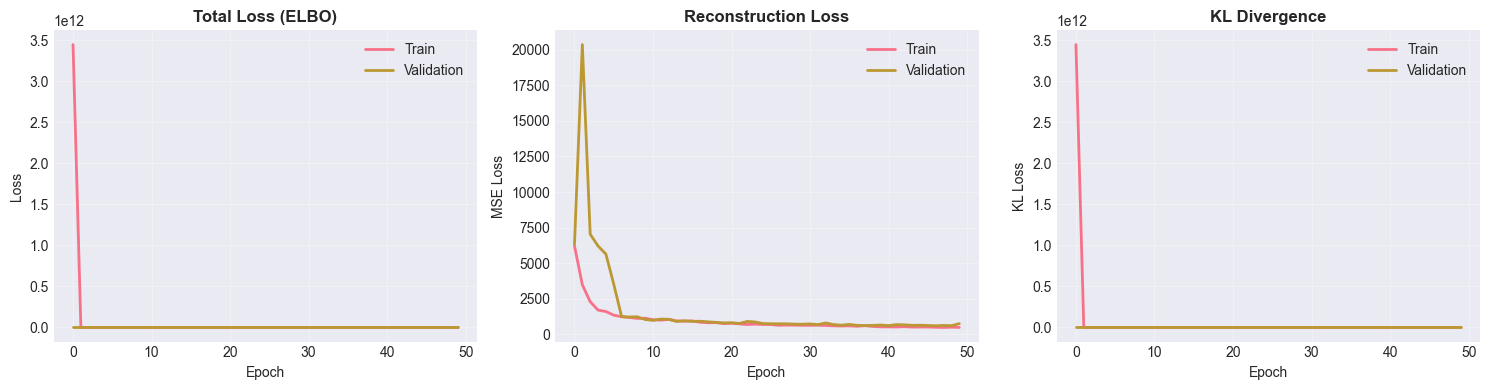

In [59]:
def plot_training_history(history):
    """
    Visualize training and validation losses over epochs.
    """
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Total Loss
    axes[0].plot(history['train_loss'], label='Train', linewidth=2)
    axes[0].plot(history['val_loss'], label='Validation', linewidth=2)
    axes[0].set_title('Total Loss (ELBO)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Reconstruction Loss
    axes[1].plot(history['train_recon_loss'], label='Train', linewidth=2)
    axes[1].plot(history['val_recon_loss'], label='Validation', linewidth=2)
    axes[1].set_title('Reconstruction Loss', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MSE Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # KL Divergence
    axes[2].plot(history['train_kl_loss'], label='Train', linewidth=2)
    axes[2].plot(history['val_kl_loss'], label='Validation', linewidth=2)
    axes[2].set_title('KL Divergence', fontsize=12, fontweight='bold')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('KL Loss')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plot training history
plot_training_history(history)


## 10. Inference and Generation

### Load Best Model


In [60]:
# Load the best model
checkpoint = torch.load('best_vae_model.pth', map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
print(f"✅ Loaded best model from epoch {checkpoint['epoch']+1}")


✅ Loaded best model from epoch 47


### Reconstruction Visualization


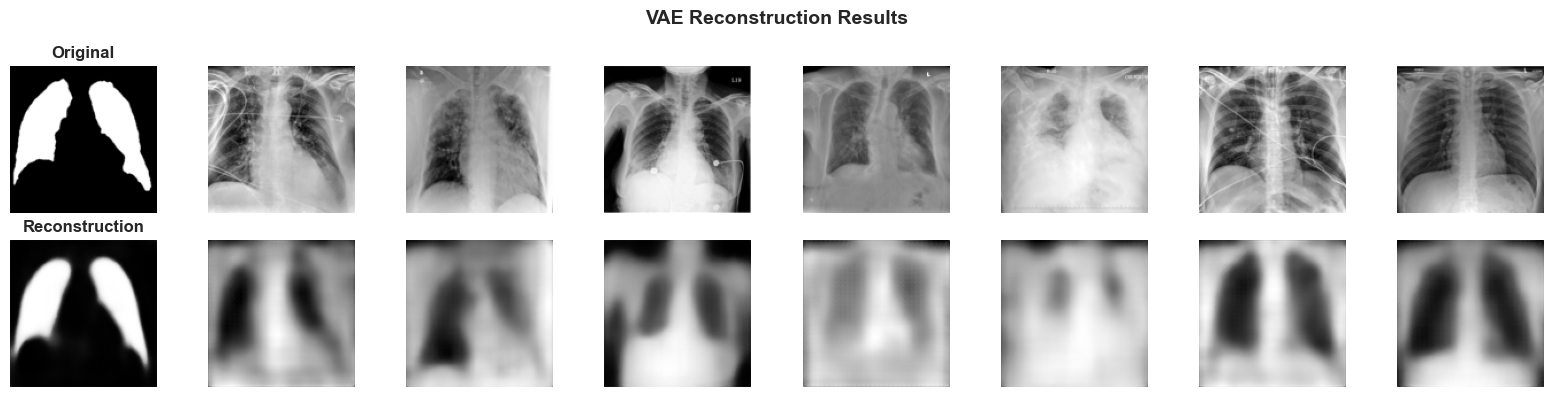

In [61]:
def visualize_reconstructions(model, dataloader, device, num_samples=8):
    """
    Visualize original images alongside their reconstructions.
    """
    model.eval()
    
    # Get a batch of data
    data = next(iter(dataloader))
    data = data[:num_samples].to(device)
    
    with torch.no_grad():
        # Get reconstructions
        recon, mu, logvar = model(data)
        
        # Denormalize images (from [-1, 1] to [0, 1])
        data_denorm = (data + 1) / 2
        recon_denorm = (recon + 1) / 2
    
    # Plot
    fig, axes = plt.subplots(2, num_samples, figsize=(num_samples*2, 4))
    
    for i in range(num_samples):
        # Original
        axes[0, i].imshow(data_denorm[i].cpu().squeeze(), cmap='gray')
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title('Original', fontweight='bold')
        
        # Reconstruction
        axes[1, i].imshow(recon_denorm[i].cpu().squeeze(), cmap='gray')
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title('Reconstruction', fontweight='bold')
    
    plt.suptitle('VAE Reconstruction Results', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Visualize reconstructions
visualize_reconstructions(model, val_loader, device)


### Random Generation


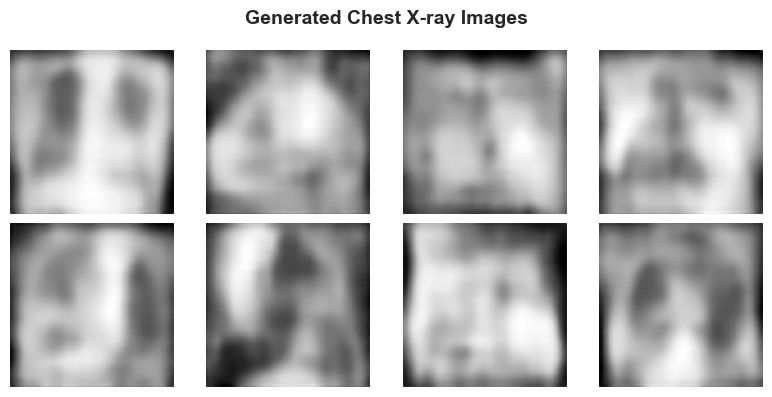

In [62]:
def generate_samples(model, num_samples, device):
    """
    Generate new samples by sampling from the latent space.
    """
    model.eval()
    
    with torch.no_grad():
        # Sample from standard Gaussian
        samples = model.sample(num_samples, device)
        
        # Denormalize
        samples = (samples + 1) / 2
    
    return samples

def visualize_generated_samples(samples, rows=2, cols=4):
    """
    Visualize generated samples in a grid.
    """
    fig, axes = plt.subplots(rows, cols, figsize=(cols*2, rows*2))
    axes = axes.flatten()
    
    for i in range(min(len(samples), rows*cols)):
        axes[i].imshow(samples[i].cpu().squeeze(), cmap='gray')
        axes[i].axis('off')
    
    plt.suptitle('Generated Chest X-ray Images', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Generate and visualize samples
generated_samples = generate_samples(model, num_samples=8, device=device)
visualize_generated_samples(generated_samples)
